# CosmoFit Quickstart

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/01-getting-started/quickstart.ipynb)

The shortest path from "nothing installed" to a real MCMC posterior:
pick a model, pick datasets, fit. This notebook fits flat ΛCDM to
Cosmic Chronometers + DESI BAO in a couple of minutes.

For a deeper dive: [`cpl_mcmc_analysis.ipynb`](../05-case-studies/cpl_mcmc_analysis.ipynb)
(full CPL dark-energy analysis with convergence diagnostics, model
comparison and every figure), [`model_zoo_comparison.ipynb`](../02-models/model_zoo_comparison.ipynb)
(all 6 cosmological models head-to-head), and
[`dataset_zoo.ipynb`](dataset_zoo.ipynb) (a tour of every built-in
dataset).

**Running this notebook:** open in Colab and *Runtime → Run all*.


## Setup

In [1]:
import sys

# On Colab, install the released package and nothing else.
#
# This used to clone the repository and install it editable,
# which needed a `sys.path` fix afterwards: pip runs in a
# subprocess, so the already-running kernel never saw the .pth
# file it wrote, and `import cosmofit` could resolve to the bare
# checkout directory instead -- same name, and /content is on
# sys.path. A normal install goes to site-packages, which is
# already there, so all of that goes away.

if "google.colab" in sys.modules:
    !pip install -q cosmofit
else:
    print("Not running in Colab -- assuming CosmoFit is already "
          'installed (pip install cosmofit).')


Not running in Colab -- assuming CosmoFit is already installed (pip install cosmofit).


## The whole workflow in one cell

`Fitter` ties together a cosmological model, a list of datasets, and
which parameters are free. Everything else -- likelihoods, priors,
the posterior, plotting -- is built for you. The sampling is done by
the library's 2.0 core: `sample_on_core` runs its adaptive
Metropolis-Hastings sampler on this fit and hands the chains back to
it, so `summary()`, `convergence()` and every figure read them.

In [2]:
from cosmofit import LCDM, Fitter

fit = Fitter(
    model=LCDM,
    datasets=["cc", "desi"],
    free_params=["H0", "Omega_m"],
    initial={"H0": 67.4, "Omega_m": 0.315, "rd": 147.1},
)

fit

Fitter(model=LCDM, datasets=['cc', 'desi'], free_params=['H0', 'Omega_m'])

In [3]:
from cosmofit.compat import sample_on_core

# Four chains that learn the posterior's covariance as they go, and
# stop once they agree: Gelman-Rubin R - 1 < 0.01.
core = sample_on_core(fit, "mcmc", {"Rminus1_stop": 0.01}, seed=0)
print(f"{core.n_chains} chains, {core.progress[-1]['steps']} steps each")

4 chains, 880 steps each


## Was that enough steps? Always check.

In [4]:
conv = fit.convergence()
rule = conv["stopping_rule"]
print(f"converged: {conv['converged']} ({rule['rule']}: now {rule['value']:.4f})")
for name, tau in conv["tau"].items():
    print(f"  {name}: tau={tau:.1f}, n_eff={conv['n_effective'][name]:.0f}")

converged: True (R - 1 < 0.01: now 0.0062)
  H0: tau=7.3, n_eff=336
  Omega_m: tau=6.9, n_eff=355


## Results

In [5]:
for name, s in fit.summary().items():
    print(f"{name:>10s} = {s['median']:.4f} +{s['plus']:.4f} / -{s['minus']:.4f}")

fit.best_fit()
print(f"\nbest fit: {fit.best_fit_params}")
print(f"chi2_min = {fit.best_fit_chi2:.2f}  ({fit.n_data} data points)")

        H0 = 69.0132 +0.4836 / -0.4721
   Omega_m = 0.2979 +0.0082 / -0.0085

best fit: {'H0': np.float64(69.0464052835211), 'Omega_m': np.float64(0.2971587892037612)}
chi2_min = 23.56  (45 data points)


## Plots

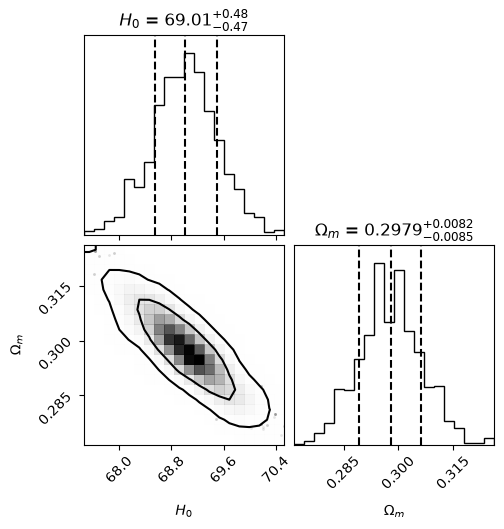

In [6]:
fig = fit.plots.corner()

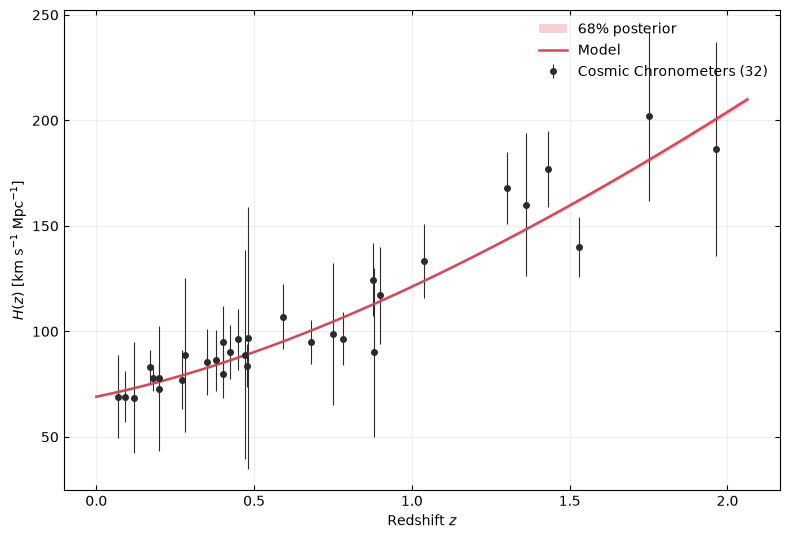

In [7]:
fig = fit.plots.hz()

## Next steps

- Swap `model=LCDM` for `CPL`, `WCDM`, `JBP`, `BA`, or `GCG` -- see
  [`model_zoo_comparison.ipynb`](../02-models/model_zoo_comparison.ipynb) for all
  six side by side.
- Add `"pantheon"`, `"des_sn5yr"`, `"sdss_bao"`, or `"planck"` to
  `datasets=[...]` -- see [`dataset_zoo.ipynb`](dataset_zoo.ipynb)
  for what each one looks like on its own (and which combinations to
  avoid).
- `fit.plots` has a lot more than `corner()`/`hz()`: try
  `hubble_diagram()`, `bao_distances()`, `w_of_z()`,
  `deceleration()`.